In [1]:
%load_ext autoreload
%autoreload 2

# Model Training: New Regression Task

`Task Description: Predict client spending amount in the next 30 days.`

In [2]:
import gc
import os
from warnings import filterwarnings

filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [3]:
import torch
from relbench.datasets import get_dataset
from relbench.modeling.graph import make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric import seed_everything

In [4]:
from experiments.model_training.training.models.hgt_model import HGTModel
from experiments.model_training.training.models.sage_model import SAGEModel
from experiments.model_training.training.text_embedder import TextEmbedder
from experiments.model_training.training.trainer import Trainer
from experiments.model_training.utils import (
    get_device,
    load_config,
    make_loaders,
    patched_to_unix_time,
)

In [5]:
import relbench.modeling.graph
import relbench.modeling.utils

relbench.modeling.graph.to_unix_time = patched_to_unix_time
relbench.modeling.utils.to_unix_time = patched_to_unix_time

In [6]:
from predql_tasks.tasks import SeznamClientSpendingTmpTask

In [7]:
seed_everything(42)
device = get_device()
config = load_config("config.yml")
cache_dir = "./.cache_predql"
dataset_name = "ctu-seznam"
task_name = "seznam_client_spending_tmp"

Using device: cuda


In [8]:
dataset = get_dataset(dataset_name, download=False)
task = SeznamClientSpendingTmpTask()
db = dataset.get_db()

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.12 seconds.


In [9]:
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'probehnuto_mimo_penezenku': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'Month_Year': <stype.timestamp: 'timestamp'>,
  'probehla_inzerce_mimo_penezenku': <stype.categorical: 'categorical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'dobito': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_dobito': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'probehnuto': {'__PK__': <stype.numerical: 'numerical'>,
  'client_id': <stype.numerical: 'numerical'>,
  'month_year_datum_transakce': <stype.timestamp: 'timestamp'>,
  'sluzba': <stype.categorical: 'categorical'>,
  'kc_proklikano': <stype.numerical: 'numerical'>,
  'FK_client_client_id': <stype.numerical: 'numerical'>},
 'client': {'__PK__': <stype.numerical: 'numerical'>,
  '

In [10]:
model_name = config["shared"]["text_embedder_model_name"]
batch_size = config["shared"]["batch_size"]

In [11]:
text_embedder = TextEmbedderConfig(
    text_embedder=TextEmbedder(
        model_name=model_name,
        device="cpu",
        cache_dir=cache_dir), batch_size=batch_size
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict,
    text_embedder,
    cache_dir=os.path.join(cache_dir, dataset_name)
)

data

HeteroData(
  probehnuto_mimo_penezenku={
    tf=TensorFrame([588990, 3]),
    time=[588990],
  },
  dobito={
    tf=TensorFrame([501626, 4]),
    time=[501626],
  },
  probehnuto={
    tf=TensorFrame([1321324, 4]),
    time=[1321324],
  },
  client={ tf=TensorFrame([73447, 2]) },
  (probehnuto_mimo_penezenku, f2p_FK_client_client_id, client)={ edge_index=[2, 588990] },
  (client, rev_f2p_FK_client_client_id, probehnuto_mimo_penezenku)={ edge_index=[2, 588990] },
  (dobito, f2p_FK_client_client_id, client)={ edge_index=[2, 501396] },
  (client, rev_f2p_FK_client_client_id, dobito)={ edge_index=[2, 501396] },
  (probehnuto, f2p_FK_client_client_id, client)={ edge_index=[2, 1321023] },
  (client, rev_f2p_FK_client_client_id, probehnuto)={ edge_index=[2, 1321023] }
)

In [12]:
loader_dict, _, _ = make_loaders(
    data,
    task,
    batch_size,
    num_neighbors=config["shared"]["num_neighbors"],
)

Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.08 seconds.
Loading Database object from /home/kolesiko/.cache/relbench/ctu-seznam/db...
Done in 0.08 seconds.


In [13]:
task_type = task.task_type

in_channels = config["shared"]["in_channels"]
learning_rate = config["shared"]["learning_rate"]
dropout = config["shared"]["dropout"]
num_epochs = config["shared"]["num_epochs"]
num_runs = config["shared"]["num_runs"]

mlp_config = config["mlp_head"]
mlp_config["out_channels"] = 1

## SAGE


MODEL INFO:
Model name: SAGE
Number of parameters: 1769217


STARTING RUN 1/5


Evaluating: 100%|██████████| 285/285 [00:02<00:00, 137.74it/s]


Epoch 1/30 | Train Loss: 10630.7343 | Train mae: 10278.2217
Epoch 1/30 |   Val Loss: 9424.5618 |   Val mae: 9424.5615
New best model found with Val mae: 9424.5615


Evaluating: 100%|██████████| 285/285 [00:02<00:00, 119.94it/s]


New best model found with Val mae: 8947.4863


...

Evaluating: 100%|██████████| 285/285 [00:02<00:00, 139.21it/s]


Epoch 15/30 | Train Loss: 9830.7562 | Train mae: 9822.1855
Epoch 15/30 |   Val Loss: 8836.9369 |   Val mae: 8836.9375
!!! No improvement in Val mae for 10 epochs (Early stopping at epoch 15) !!!


Evaluating: 100%|██████████| 275/275 [00:01<00:00, 141.47it/s]


Run 5/5 | Final Train Metrics: {'mae': 9830.828125, 'mse': 4195235840.0, 'r2': -0.012508273124694824, 'loss': 9830.82832101325}
Run 5/5 | Final Val Metrics: {'mae': 8827.1982421875, 'mse': 2096437760.0, 'r2': -0.018947362899780273, 'loss': 8827.197425544726}
Run 5/5 | Final Test Metrics: {'mae': 9306.7197265625, 'mse': 3109884672.0, 'r2': -0.014379620552062988, 'loss': 9306.718827472716}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Mae: 9825.7598 ± 3.2643
  Mse: 4194827520.0000 ± 457774.6446
  R2: -0.0124 ± 0.0001
  Loss: 9825.7599 ± 3.2644

[VAL] Metrics:
  Mae: 8826.1424 ± 1.1119
  Mse: 2096096665.6000 ± 336840.9574
  R2: -0.0188 ± 0.0002
  Loss: 8826.1420 ± 1.1119

[TEST] Metrics:
  Mae: 9306.8711 ± 1.5433
  Mse: 3109679872.0000 ± 325721.9901
  R2: -0.0143 ± 0.0001
  Loss: 9306.8709 ± 1.5437



12

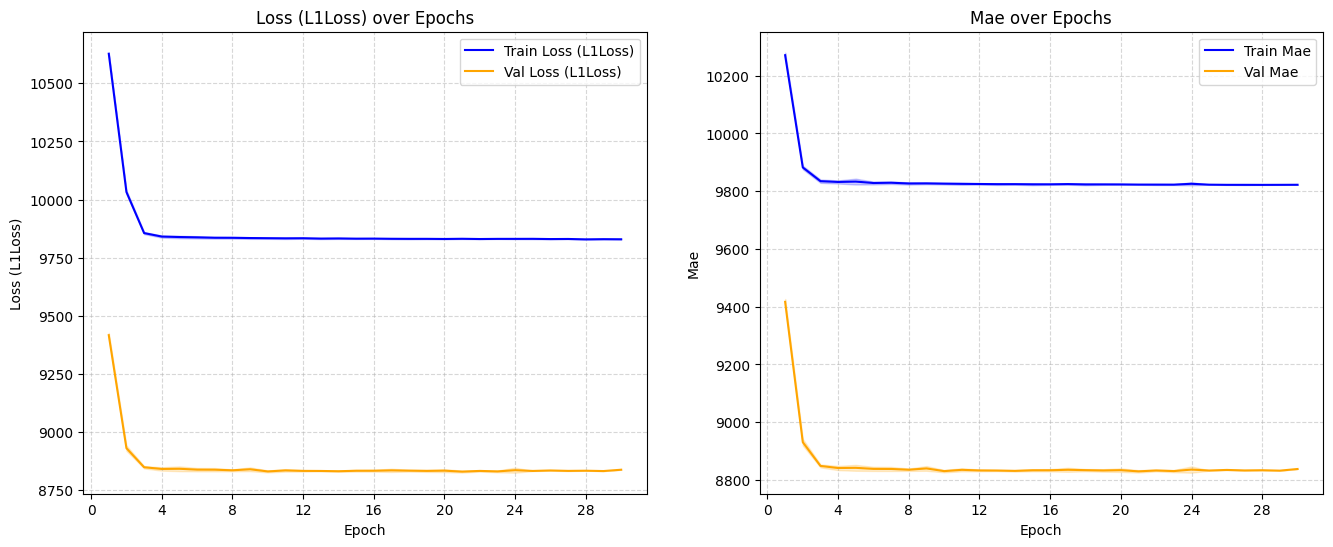

In [14]:
sage_model = SAGEModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["sage"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.L1Loss()
optimizer = torch.optim.AdamW(sage_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=sage_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="mae",
    higher_is_better=False,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{sage_model.gnn_name}_{task_name}_best_weights.pt"))

del sage_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()

## HGT


MODEL INFO:
Model name: HGT
Number of parameters: 2264625


STARTING RUN 1/5


Evaluating: 100%|██████████| 285/285 [00:02<00:00, 117.88it/s]


Epoch 1/30 | Train Loss: 10622.5669 | Train mae: 10263.7061
Epoch 1/30 |   Val Loss: 9407.0863 |   Val mae: 9407.0859
New best model found with Val mae: 9407.0859


Evaluating: 100%|██████████| 285/285 [00:02<00:00, 118.34it/s]


New best model found with Val mae: 8950.2334


...

Evaluating: 100%|██████████| 285/285 [00:03<00:00, 76.66it/s]


!!! No improvement in Val mae for 10 epochs (Early stopping at epoch 20) !!!


Evaluating: 100%|██████████| 275/275 [00:03<00:00, 74.76it/s]


Run 5/5 | Final Train Metrics: {'mae': 9827.7900390625, 'mse': 4193157376.0, 'r2': -0.012006521224975586, 'loss': 9827.790006934}
Run 5/5 | Final Val Metrics: {'mae': 8839.83203125, 'mse': 2095200768.0, 'r2': -0.018346071243286133, 'loss': 8839.832589036474}
Run 5/5 | Final Test Metrics: {'mae': 9321.6484375, 'mse': 3108712192.0, 'r2': -0.013997197151184082, 'loss': 9321.648669417245}
FINISHED RUN 5/5


FINAL STATS OVER 5 RUNS

[TRAIN] Metrics:
  Mae: 9828.5539 ± 1.8360
  Mse: 4193267968.0000 ± 327212.3062
  R2: -0.0120 ± 0.0001
  Loss: 9828.5538 ± 1.8362

[VAL] Metrics:
  Mae: 8839.1031 ± 3.0590
  Mse: 2095346355.2000 ± 248084.0195
  R2: -0.0184 ± 0.0001
  Loss: 8839.1032 ± 3.0592

[TEST] Metrics:
  Mae: 9321.0258 ± 2.8790
  Mse: 3108812544.0000 ± 262530.8645
  R2: -0.0140 ± 0.0001
  Loss: 9321.0258 ± 2.8791



15

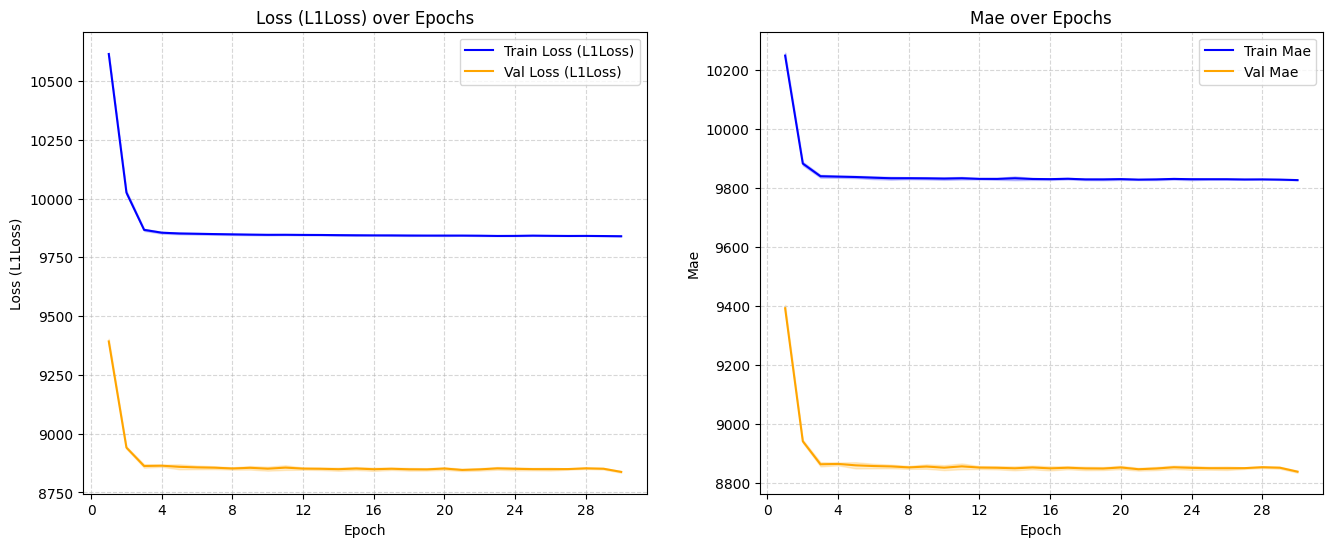

In [15]:
hgt_model = HGTModel(
    data=data,
    col_stats_dict=col_stats_dict,
    in_channels=in_channels,
    gnn_config=config["gnn_heads"]["hgt"],
    mlp_config=mlp_config,
    task_type=task_type,
    dropout=dropout
).to(device)

criterion = torch.nn.L1Loss()
optimizer = torch.optim.AdamW(hgt_model.parameters(), lr=learning_rate)

trainer = Trainer(
    task=task,
    model=hgt_model,
    optimizer=optimizer,
    criterion=criterion,
    device=device
)

trainer.run_experiment(
    loader_dict,
    num_epochs,
    tune_metric="mae",
    higher_is_better=False,
    patience=10,
    print_every=3,
    num_runs=num_runs
)

# torch.save(best_weights, os.path.join(cache_dir, dataset_name, f"{hgt_model.gnn_name}_{task_name}_best_weights.pt"))

del hgt_model, optimizer, trainer
torch.cuda.empty_cache()
gc.collect()